<a href="https://colab.research.google.com/github/mhkbin/AIML-Lab/blob/main/Statement1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.



BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


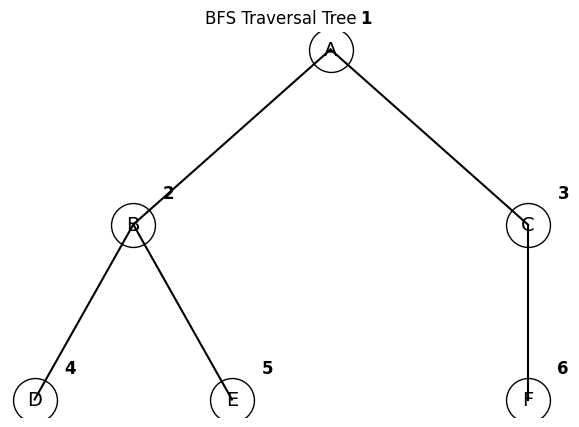

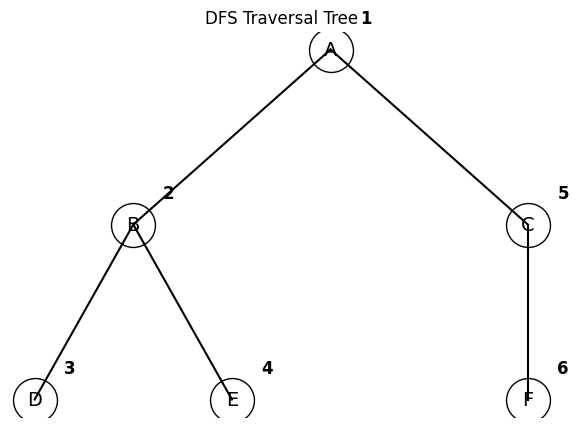

In [2]:
import matplotlib.pyplot as plt
from collections import deque

# Adjacency List
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B'],
    'F': ['C']
}


# BFS Traversal
def bfs(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.append(node)

            for neighbour in graph[node]:
                if neighbour not in visited:
                    queue.append(neighbour)

    return visited


# DFS Traversal
def dfs(graph, start, visited=None):
    if visited is None:
        visited = []

    visited.append(start)

    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited)

    return visited


# Perform BFS and DFS
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

# Print traversal orders
print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# Function to draw the tree
def draw_tree(order, title):
    positions = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    plt.figure(figsize=(7, 5))

    # Draw edges
    edges = [('A', 'B'), ('A', 'C'),
             ('B', 'D'), ('B', 'E'),
             ('C', 'F')]

    for node1, node2 in edges:
        x1, y1 = positions[node1]
        x2, y2 = positions[node2]
        plt.plot([x1, x2], [y1, y2], 'k-')

    # Draw nodes
    for node, (x, y) in positions.items():
        plt.scatter(x, y, s=1000, facecolors='white', edgecolors='black')
        plt.text(x, y, node, ha='center', va='center', fontsize=14)

    # Add visiting order
    for i, node in enumerate(order, start=1):
        x, y = positions[node]
        plt.text(x + 0.15, y + 0.15, str(i),
                 fontsize=12, fontweight='bold')

    plt.title(title)
    plt.axis('off')
    plt.show()


# Draw BFS tree
draw_tree(bfs_order, "BFS Traversal Tree")

# Draw DFS tree
draw_tree(dfs_order, "DFS Traversal Tree")